In [1]:

# VAE with 5-Fold Evaluation
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

df = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")
df = df[["smiles","HIV_active"]].dropna().reset_index(drop=True)
print(df.head())
print(df.shape)


                                        smiles  HIV_active
0                             CNC(=O)Nc1ccncc1           0
1                      O=C1NC(O)c2cccc(Cl)c2O1           0
2                       O=S1(=O)C=Cc2ccccc2CC1           0
3    Cc1ccc(OS(=O)(=O)c2ccccc2[N+](=O)[O-])cc1           1
4  CN(c1ccccc1)S(=O)(=O)c1cccc([N+](=O)[O-])c1           1
(2885, 2)


In [2]:

# Character-level encoding
chars = sorted(set("".join(df["smiles"].astype(str).tolist())))
char_to_int = {c: i + 1 for i, c in enumerate(chars)}  # 0 reserved for padding
max_len = int(df["smiles"].str.len().max())

def encode_smiles(smiles):
    seq = [char_to_int[c] for c in smiles]
    seq = seq + [0] * (max_len - len(seq))
    return seq[:max_len]

X = np.array([encode_smiles(s) for s in df["smiles"]], dtype=np.int32)
y = df["HIV_active"].astype(int).values

vocab_size = len(char_to_int) + 1
print("X shape:", X.shape, "y shape:", y.shape, "vocab_size:", vocab_size, "max_len:", max_len)


X shape: (2885, 400) y shape: (2885,) vocab_size: 53 max_len: 400


In [3]:

LATENT_DIM = 32
EMBED_DIM = 32
LSTM_UNITS = 32
BATCH_SIZE = 16
EPOCHS = 200
PATIENCE = 5
LR = 1e-6

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae(seq_len, vocab_size, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, latent_dim=LATENT_DIM, lr=LR):
    encoder_inputs = layers.Input(shape=(seq_len,), name="encoder_input")
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=False)(encoder_inputs)
    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

    latent_inputs = layers.Input(shape=(latent_dim,), name="z_sampling")
    d = layers.RepeatVector(seq_len)(latent_inputs)
    d = layers.LSTM(lstm_units * 2, return_sequences=True)(d)
    decoder_outputs = layers.TimeDistributed(
        layers.Dense(vocab_size, activation="softmax")
    )(d)

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
    decoder = Model(latent_inputs, decoder_outputs, name="decoder")

    outputs = decoder(encoder(encoder_inputs)[2])

    class VAE(Model):
        def __init__(self, encoder, decoder, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
            self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
            self.recon_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
            self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
            self.token_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
            self.val_token_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name="val_accuracy")

        @property
        def metrics(self):
            return [
                self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker,
                self.token_accuracy,
                self.val_token_accuracy,
            ]

        def train_step(self, data):
            x = data
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(x)
                reconstruction = self.decoder(z)
                x_onehot = tf.one_hot(tf.cast(x, tf.int32), depth=vocab_size)
                recon_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        tf.keras.losses.categorical_crossentropy(x_onehot, reconstruction),
                        axis=1
                    )
                )
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
                )
                total_loss = recon_loss + 0.01 * kl_loss
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.recon_loss_tracker.update_state(recon_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            self.token_accuracy.update_state(tf.cast(x, tf.int32), reconstruction)
            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
                "accuracy": self.token_accuracy.result(),
            }

        def test_step(self, data):
            x = data
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            x_onehot = tf.one_hot(tf.cast(x, tf.int32), depth=vocab_size)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.categorical_crossentropy(x_onehot, reconstruction),
                    axis=1
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + 0.01 * kl_loss
            self.total_loss_tracker.update_state(total_loss)
            self.recon_loss_tracker.update_state(recon_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            self.token_accuracy.update_state(tf.cast(x, tf.int32), reconstruction)
            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
                "accuracy": self.token_accuracy.result(),
            }

        def call(self, inputs):
            z_mean, z_log_var, z = self.encoder(inputs)
            return self.decoder(z)

    vae = VAE(encoder, decoder)
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr))
    return vae, encoder, decoder


In [4]:

def run_fold(train_df, val_df, test_df, fold_id):
    X_train = np.array([encode_smiles(s) for s in train_df["smiles"]], dtype=np.int32)
    X_val   = np.array([encode_smiles(s) for s in val_df["smiles"]], dtype=np.int32)
    X_test  = np.array([encode_smiles(s) for s in test_df["smiles"]], dtype=np.int32)

    y_train = train_df["HIV_active"].astype(int).values
    y_val   = val_df["HIV_active"].astype(int).values
    y_test  = test_df["HIV_active"].astype(int).values

    tf.keras.backend.clear_session()
    np.random.seed(SEED + fold_id)
    tf.random.set_seed(SEED + fold_id)

    vae, encoder, decoder = build_vae(seq_len=max_len, vocab_size=vocab_size)

    early_stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history = vae.fit(
        X_train,
        validation_data=(X_val, None),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0,
        shuffle=True
    )

    z_mean_train, _, _ = encoder.predict(X_train, verbose=0)
    z_mean_val, _, _   = encoder.predict(X_val, verbose=0)
    z_mean_test, _, _  = encoder.predict(X_test, verbose=0)

    scaler = StandardScaler()
    z_train = scaler.fit_transform(z_mean_train)
    z_val   = scaler.transform(z_mean_val)
    z_test  = scaler.transform(z_mean_test)

    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED + fold_id)
    clf.fit(z_train, y_train)

    val_prob = clf.predict_proba(z_val)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.02)
    best_thr, best_f1 = 0.5, -1.0
    for thr in thresholds:
        val_pred = (val_prob >= thr).astype(int)
        f1 = f1_score(y_val, val_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    test_prob = clf.predict_proba(z_test)[:, 1]
    test_pred = (test_prob >= best_thr).astype(int)

    fold_result = {
        "fold": fold_id,
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "best_threshold": best_thr,
        "epochs_ran": len(history.history["loss"])
    }
    return fold_result, history.history


In [5]:

all_fold_results = []
all_histories = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_index = np.arange(len(df))
y_all = df["HIV_active"].values

for fold_id, (train_idx, temp_idx) in enumerate(skf.split(X_index, y_all), start=1):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    val_idx, test_idx = train_test_split(
        np.arange(len(temp_df)),
        test_size=0.5,
        random_state=SEED + fold_id,
        stratify=temp_df["HIV_active"]
    )

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    print(f"\n===== Fold {fold_id} =====")
    print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

    fold_result, hist = run_fold(train_df, val_df, test_df, fold_id)
    print(fold_result)
    all_fold_results.append(fold_result)
    all_histories.append(hist)

results_df = pd.DataFrame(all_fold_results)
results_df



===== Fold 1 =====
Train: 2308 Val: 288 Test: 289
Restoring model weights from the end of the best epoch: 200.
{'fold': 1, 'test_accuracy': 0.7681660899653979, 'test_precision': 0.8174603174603174, 'test_recall': 0.7006802721088435, 'test_f1': 0.7545787545787546, 'test_roc_auc': np.float64(0.8395132700967711), 'best_threshold': 0.5800000000000001, 'epochs_ran': 200}

===== Fold 2 =====
Train: 2308 Val: 288 Test: 289
Restoring model weights from the end of the best epoch: 200.
{'fold': 2, 'test_accuracy': 0.8166089965397924, 'test_precision': 0.8405797101449275, 'test_recall': 0.7891156462585034, 'test_f1': 0.8140350877192982, 'test_roc_auc': np.float64(0.8797547187889241), 'best_threshold': 0.56, 'epochs_ran': 200}

===== Fold 3 =====
Train: 2308 Val: 288 Test: 289
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.
{'fold': 3, 'test_accuracy': 0.6885813148788927, 'test_precision': 0.657608695652174, 'test_recall': 0.8175675675675675, 'test_f1': 0.72891

,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_threshold,epochs_ran
0,1,0.768166,0.817460,0.700680,0.754579,0.839513,0.58,200
1,2,0.816609,0.840580,0.789116,0.814035,0.879755,0.56,200
2,3,0.688581,0.657609,0.817568,0.728916,0.792362,0.46,12
3,4,0.854671,0.848684,0.871622,0.860000,0.914702,0.52,200
4,5,0.640138,0.617021,0.783784,0.690476,0.734618,0.44,6


In [6]:

metrics = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]

summary_rows = []
for m in metrics:
    mean = results_df[m].mean()
    std = results_df[m].std(ddof=1)
    var = results_df[m].var(ddof=1)
    summary_rows.append({
        "Metric": m.replace("test_", "").upper(),
        "Mean": mean,
        "Std": std,
        "Variance": var,
        "Formatted": f"{mean:.3f} ± {std:.3f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.753633,0.088739,0.007875,0.754 ± 0.089
1,PRECISION,0.756271,0.110133,0.012129,0.756 ± 0.110
2,RECALL,0.792554,0.062062,0.003852,0.793 ± 0.062
3,F1,0.769601,0.067617,0.004572,0.770 ± 0.068
4,ROC_AUC,0.832190,0.071118,0.005058,0.832 ± 0.071


In [7]:

final_table = pd.DataFrame([{
    "Model": "VAE",
    "Accuracy": summary_df.loc[summary_df["Metric"] == "ACCURACY", "Formatted"].values[0],
    "Precision": summary_df.loc[summary_df["Metric"] == "PRECISION", "Formatted"].values[0],
    "Recall": summary_df.loc[summary_df["Metric"] == "RECALL", "Formatted"].values[0],
    "F1": summary_df.loc[summary_df["Metric"] == "F1", "Formatted"].values[0],
    "ROC-AUC": summary_df.loc[summary_df["Metric"] == "ROC_AUC", "Formatted"].values[0],
}])

results_df.to_csv("VAE_fold_results.csv", index=False)
summary_df.to_csv("VAE_summary_results.csv", index=False)
final_table.to_csv("VAE_final_table.csv", index=False)

print("Fold-wise results:")
display(results_df)
print("\nSummary results:")
display(summary_df)
print("\nFinal table:")
display(final_table)


Fold-wise results:


,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_threshold,epochs_ran
0,1,0.768166,0.817460,0.700680,0.754579,0.839513,0.58,200
1,2,0.816609,0.840580,0.789116,0.814035,0.879755,0.56,200
2,3,0.688581,0.657609,0.817568,0.728916,0.792362,0.46,12
3,4,0.854671,0.848684,0.871622,0.860000,0.914702,0.52,200
4,5,0.640138,0.617021,0.783784,0.690476,0.734618,0.44,6



Summary results:


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.753633,0.088739,0.007875,0.754 ± 0.089
1,PRECISION,0.756271,0.110133,0.012129,0.756 ± 0.110
2,RECALL,0.792554,0.062062,0.003852,0.793 ± 0.062
3,F1,0.769601,0.067617,0.004572,0.770 ± 0.068
4,ROC_AUC,0.832190,0.071118,0.005058,0.832 ± 0.071



Final table:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,VAE,0.754 ± 0.089,0.756 ± 0.110,0.793 ± 0.062,0.770 ± 0.068,0.832 ± 0.071


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

max_len_hist = max(len(h["loss"]) for h in all_histories)

def pad_hist(hist_list, key, target_len):
    arr = []
    for h in hist_list:
        vals = h.get(key, [])
        if len(vals) == 0:
            vals = [np.nan] * target_len
        elif len(vals) < target_len:
            vals = vals + [vals[-1]] * (target_len - len(vals))
        arr.append(vals)
    return np.array(arr, dtype=float)

def smooth_curve(values, window=5):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        smoothed.append(np.nanmean(values[start:i+1]))
    return np.array(smoothed)

print("Available keys in first history:")
print(list(all_histories[0].keys()))


Available keys in first history:
['accuracy', 'kl_loss', 'loss', 'reconstruction_loss', 'val_accuracy', 'val_kl_loss', 'val_loss', 'val_reconstruction_loss']


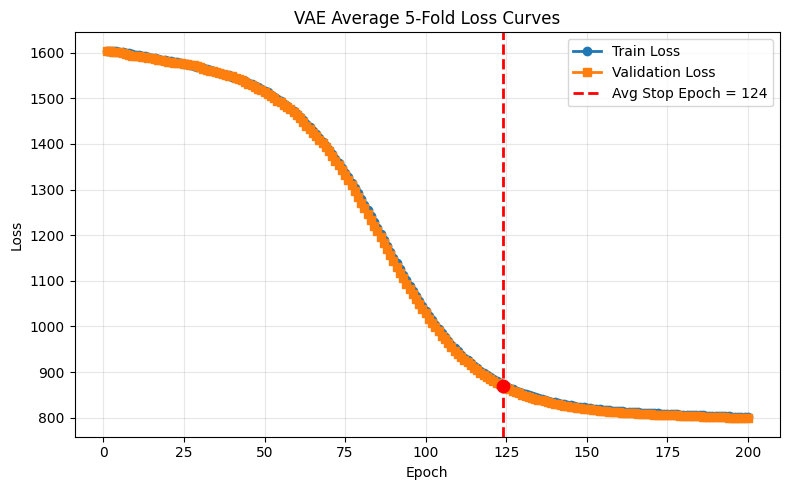

Fold-based stop epochs: [200, 200, 12, 200, 6]
Average stop epoch: 123.6


In [9]:
# === Average VAE loss curves across 5 folds ===

loss_arr = pad_hist(all_histories, "loss", max_len_hist)
val_loss_arr = pad_hist(all_histories, "val_loss", max_len_hist)

avg_train_loss = np.nanmean(loss_arr, axis=0)
avg_val_loss = np.nanmean(val_loss_arr, axis=0)

stop_epochs = [len(h["loss"]) for h in all_histories]
visual_stop_epoch = int(round(np.mean(stop_epochs)))
visual_stop_epoch = max(1, min(visual_stop_epoch, max_len_hist))

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_train_loss, window=5), marker='o', linewidth=2, label="Train Loss")
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_val_loss, window=5), marker='s', linewidth=2, label="Validation Loss")

plt.axvline(x=visual_stop_epoch, color='red', linestyle='--', linewidth=2, label=f"Avg Stop Epoch = {visual_stop_epoch}")
plt.scatter(visual_stop_epoch, smooth_curve(avg_val_loss, window=5)[visual_stop_epoch - 1], color='red', s=80, zorder=5)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Average 5-Fold Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Fold-based stop epochs:", stop_epochs)
print("Average stop epoch:", round(np.mean(stop_epochs), 2))


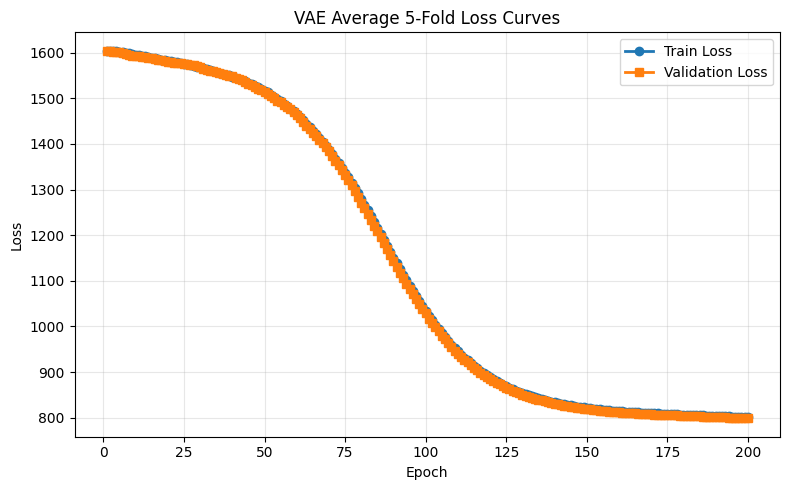

Fold-based stop epochs: [200, 200, 12, 200, 6]
Average stop epoch: 123.6


In [13]:
# === Average VAE loss curves across 5 folds ===

loss_arr = pad_hist(all_histories, "loss", max_len_hist)
val_loss_arr = pad_hist(all_histories, "val_loss", max_len_hist)

avg_train_loss = np.nanmean(loss_arr, axis=0)
avg_val_loss = np.nanmean(val_loss_arr, axis=0)

stop_epochs = [len(h["loss"]) for h in all_histories]

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_train_loss, window=5), marker='o', linewidth=2, label="Train Loss")
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_val_loss, window=5), marker='s', linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Average 5-Fold Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Fold-based stop epochs:", stop_epochs)
print("Average stop epoch:", round(np.mean(stop_epochs), 2))

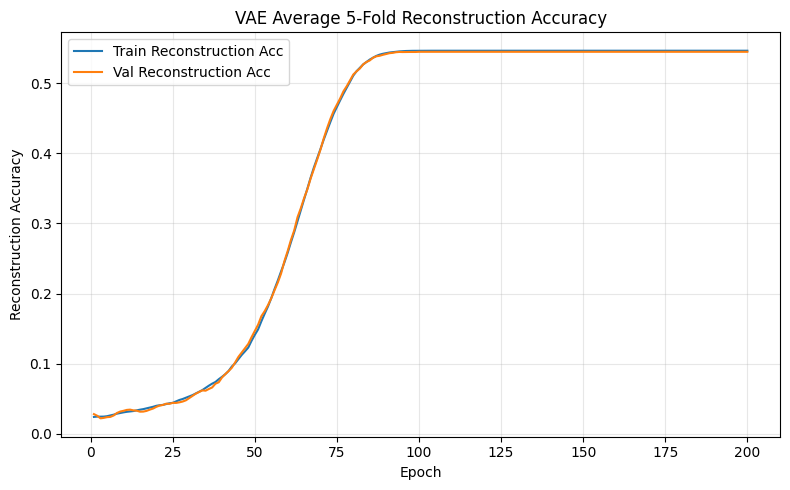

In [14]:
# === Reconstruction Accuracy ===

acc_arr = pad_hist(all_histories, "accuracy", max_len_hist)
val_acc_arr = pad_hist(all_histories, "val_accuracy", max_len_hist)

avg_train_acc = np.nanmean(acc_arr, axis=0)
avg_val_acc = np.nanmean(val_acc_arr, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_train_acc, 5), label="Train Reconstruction Acc")
plt.plot(range(1, max_len_hist + 1), smooth_curve(avg_val_acc, 5), label="Val Reconstruction Acc")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Accuracy")
plt.title("VAE Average 5-Fold Reconstruction Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

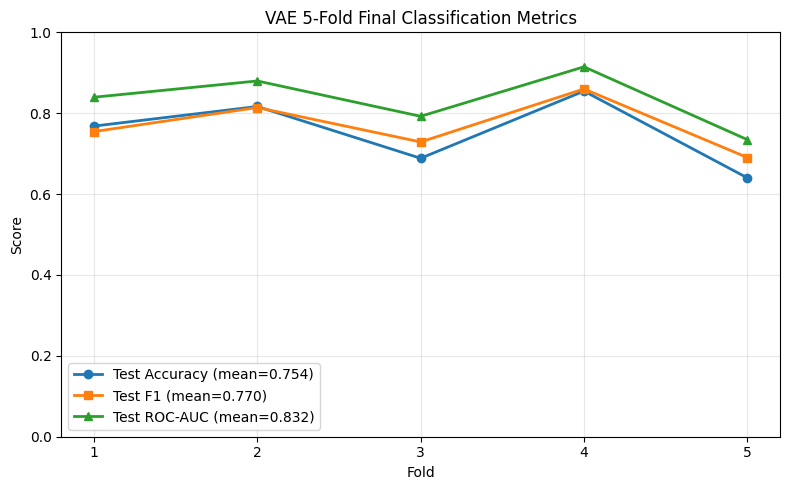

In [10]:
# === Fold-based classification metrics ===


folds = results_df["fold"].tolist()
test_acc = results_df["test_accuracy"].tolist()
test_f1 = results_df["test_f1"].tolist()
test_auc = results_df["test_roc_auc"].tolist()

fig = plt.figure(figsize=(8, 5))
plt.plot(folds, test_acc, marker='o', linewidth=2, label=f"Test Accuracy (mean={np.mean(test_acc):.3f})")
plt.plot(folds, test_f1, marker='s', linewidth=2, label=f"Test F1 (mean={np.mean(test_f1):.3f})")
plt.plot(folds, test_auc, marker='^', linewidth=2, label=f"Test ROC-AUC (mean={np.mean(test_auc):.3f})")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("VAE 5-Fold Final Classification Metrics")
plt.xticks(folds)
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


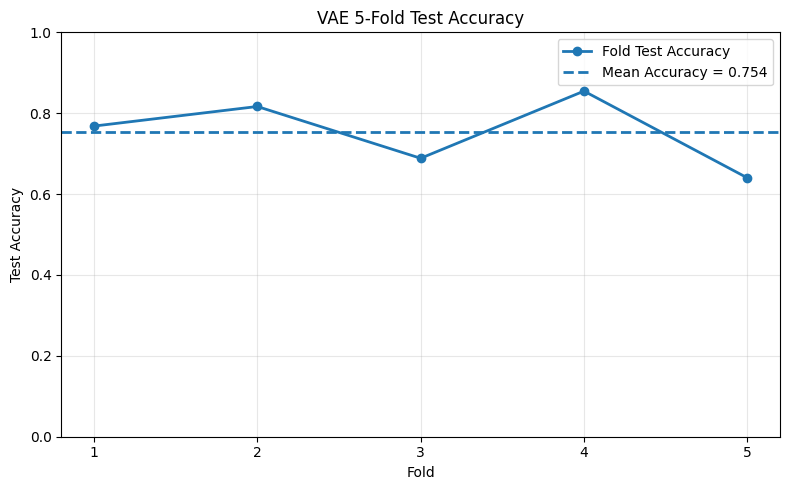

Mean Test Accuracy: 0.754
Std Test Accuracy: 0.089


In [11]:
# === Fold-based test accuracy  ===

folds = results_df["fold"].tolist()
test_acc = np.array(results_df["test_accuracy"].tolist(), dtype=float)

plt.figure(figsize=(8, 5))
plt.plot(folds, test_acc, marker='o', linewidth=2, label="Fold Test Accuracy")
plt.axhline(np.mean(test_acc), linestyle='--', linewidth=2, label=f"Mean Accuracy = {np.mean(test_acc):.3f}")
plt.xlabel("Fold")
plt.ylabel("Test Accuracy")
plt.title("VAE 5-Fold Test Accuracy")
plt.xticks(folds)
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean Test Accuracy:", round(np.mean(test_acc), 3))
print("Std Test Accuracy:", round(np.std(test_acc, ddof=1), 3))


In [12]:
# === Early stopping summary ===

fold_stop_table = pd.DataFrame({
    "Fold": list(range(1, len(all_histories) + 1)),
    "Stop_Epoch": [len(h["loss"]) for h in all_histories]
})
fold_stop_table


,Fold,Stop_Epoch
0,1,200
1,2,200
2,3,12
3,4,200
4,5,6
